# 1. INTRODUÇÃO

Um estudo gerado pela OMS em 2024, que coleu os dados de 2020 até 2021, cerca de 13% das mortes globais são causadas pela Doença Cardíaca Isquêmica, o que representa 9,1 milhões de mortes em 2021. Sendo o principal causador da mortalidade humana, não somente nesse recorte de tempo, porem em anos anteriores também é possível ver que doenças cardíacas figuram o principal causador de mortes em nós seres humanos, AVC's nessa pesquisa estão em 3º lugar. Esse dataset possui 11 varíaveis que podem ser usadas para prever a possíbilidade de doenças cardíacas, para isso iremos usar modelos de machine learning

Dataset:
1. Age: age of the patient [years]
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: oldpeak = ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: output class [1: heart disease, 0: Normal]

**FONTE**  
Este conjunto de dados foi criado combinando diferentes conjuntos de dados já disponíveis independentemente, mas que não haviam sido combinados anteriormente. Nele, 5 conjuntos de dados cardíacos foram combinados com base em 11 características comuns, o que o torna o maior conjunto de dados sobre doenças cardíacas disponível até o momento para fins de pesquisa. Os cinco conjuntos de dados utilizados para sua curadoria são:

Cleveland: 303 observações
Hungria: 294 observações
Suíça: 123 observações
Long Beach, Virgínia: 200 observações
Conjunto de dados Stalog (Coração): 270 observações
Total: 1190 observações
Duplicadas: 272 observações
Conjunto de dados final: 918 observações

## 1.2. Objetivo 
A ideia do projeto é produzir um dataset que saberá quais indicadores são os mais provaveis de influenciar em doenças cardiacas e depois produzir um dashboard em Power BI onde médicos podem colocar os resultados dos exames e o dashboard indica o risco de doença cardíaca

# 2. BIBLIOTECAS E PRÉ-PROCESSAMENTO

## 2.1. Bibliotecas

In [1]:
#Bibliotecas
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, precision_recall_curve,  average_precision_score, recall_score, 
    roc_curve, precision_score, f1_score, accuracy_score, ConfusionMatrixDisplay, brier_score_loss
    )
from sklearn.calibration import CalibrationDisplay

import warnings; warnings.filterwarnings('ignore')

SEED = 42 
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False, 
    'font.size': 11, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
})

COLORS = {'no_disease': '#2196F3', 'disease': '#F44336', 'accent': '#FF9800', 'green': '#4CAF50'}

print('Pronto')

Pronto


## 2.2. Data Munging
Objetivo aqui é tratar os dados, avaliar se há nulos ou duplicados, verificar se o tipo de cada varíavel faz sentido com o que ela representam dentro do dataset, e o que fazer mediante a essas situações.

In [2]:
#Dataset
df = pd.read_csv("heart.csv")

In [3]:
#Informações gerais sobre o dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [4]:
#Visualização das primeiras linhas do dataset
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
#Estatísticas descritivas do dataset
print(df.describe().round(2).to_string())

          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  HeartDisease
count  918.00     918.00       918.00     918.00  918.00   918.00        918.00
mean    53.51     132.40       198.80       0.23  136.81     0.89          0.55
std      9.43      18.51       109.38       0.42   25.46     1.07          0.50
min     28.00       0.00         0.00       0.00   60.00    -2.60          0.00
25%     47.00     120.00       173.25       0.00  120.00     0.00          0.00
50%     54.00     130.00       223.00       0.00  138.00     0.60          1.00
75%     60.00     140.00       267.00       0.00  156.00     1.50          1.00
max     77.00     200.00       603.00       1.00  202.00     6.20          1.00


In [6]:
#avaliando a quantidade de valores nulos
valor_nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(1) 
})
print("\nNúmero de valores nulos e a porcentagem:")
print(valor_nulos)
print(f"\nDuplicados: {df.duplicated().sum()}")
print(f"\nDistribuição da variavel Heart Disease:")
print(df['HeartDisease'].value_counts())



Número de valores nulos e a porcentagem:
                nulos  nulos_%
Age                 0      0.0
Sex                 0      0.0
ChestPainType       0      0.0
RestingBP           0      0.0
Cholesterol         0      0.0
FastingBS           0      0.0
RestingECG          0      0.0
MaxHR               0      0.0
ExerciseAngina      0      0.0
Oldpeak             0      0.0
ST_Slope            0      0.0
HeartDisease        0      0.0

Duplicados: 0

Distribuição da variavel Heart Disease:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [7]:
#Distribuição da variável alvo (HeartDisease)
target_counts = df['HeartDisease'].value_counts()
target_pct    = df['HeartDisease'].value_counts(normalize=True) * 100
 
print(f"\n  Sem doença (0): {target_counts[0]} pacientes ({target_pct[0]:.1f}%)")
print(f"  Com doença  (1): {target_counts[1]} pacientes ({target_pct[1]:.1f}%)")
 
#Determinando se o dataset possui as varíaveis de heart disease balanceadas ou desbalanceadas
ratio = target_counts[1] / target_counts[0]
print(f"\n  Ratio doença/saudável: {ratio:.2f}")
 
if 0.8 <= ratio <= 1.25:
    status = "BALANCEADO — não exige técnicas de resampling"
elif 0.5 <= ratio <= 2.0:
    status = "LEVEMENTE DESBALANCEADO — monitorar Recall"
else:
    status = "DESBALANCEADO — considerar SMOTE ou class_weight"
print(f"  Status: {status}")


  Sem doença (0): 410 pacientes (44.7%)
  Com doença  (1): 508 pacientes (55.3%)

  Ratio doença/saudável: 1.24
  Status: BALANCEADO — não exige técnicas de resampling


**Pontos a notar:**

- Sem valores faltantes: dataset limpo
- Aproximadamente 55% tem doenças cardiacas
- Cholesterol tem min = 0 o que não faz sentido já que é humanamente impossível ter
- RestingBP mesmo problema, min = 0
- valores categóricos (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope, FastingBS) e valores númericos (Age, RestingBP, Cholesterol, MaxHR, Oldpeak)

In [8]:
#Anomalias clinicamente impossíveis
zeros_chol = (df['Cholesterol'] == 0).sum()
print(f"\nCholesterol = 0: {zeros_chol} registros ({zeros_chol/len(df)*100:.1f}%)")
print(f"Mediana geral (excluindo zeros): {df[df['Cholesterol'] > 0]['Cholesterol'].median():.1f} mg/dL")
print(f"Mediana grupo com doença (excl.zeros): {df[(df['Cholesterol'] > 0) & (df['HeartDisease'] == 1)]['Cholesterol'].median():.1f} mg/dL")
print(f"  Zeros em pacientes COM doença: {((df['Cholesterol'] == 0) & (df['HeartDisease'] == 1)).sum()}")
print(f"  Zeros em pacientes SEM doença: {((df['Cholesterol'] == 0) & (df['HeartDisease'] == 0)).sum()}")


Cholesterol = 0: 172 registros (18.7%)
Mediana geral (excluindo zeros): 237.0 mg/dL
Mediana grupo com doença (excl.zeros): 246.0 mg/dL
  Zeros em pacientes COM doença: 152
  Zeros em pacientes SEM doença: 20


In [9]:
zeros_bp = (df['RestingBP'] == 0).sum()
print(f"\nRestingBP = 0: {zeros_bp}")


RestingBP = 0: 1


Para imputar os dados que estão como 0 em:  
**- Cholesterol:** utilizaremos a mediana referente a cada um dos: Saudáveis e Doente. Utilizaremos essa estratégia por 2 motivos: se usassemos a média estáriamos correndo o risco de contaminar o resultado da analise pelos outliers, e o quadro clínico dos pacientes saudáveis e dos doentes é diferente e fazer uma média geral seria colocar ambos como iguais, sendo que não são.  
**- RestingBP:** aqui também usaremos a mediana.

In [10]:
#COlocando os valores da mediana para os valores de colesterol e pressão arterial que estão como 0, pois não é possível ter esses valores em um paciente.
mediana_saudavel = df[(df['Cholesterol'] > 0) & (df['HeartDisease'] == 0)]['Cholesterol'].median()
mediana_doente = df[(df['Cholesterol'] > 0) & (df['HeartDisease'] == 1)]['Cholesterol'].median()

df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), 'Cholesterol'] = mediana_saudavel
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), 'Cholesterol'] = mediana_doente

#Restingbp
mediana_bp = df[df['RestingBP'] > 0]['RestingBP'].median()
df.loc[df['RestingBP'] == 0, 'RestingBP'] = mediana_bp

display(df.describe().round(2))

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.54,244.58,0.23,136.81,0.89,0.55
std,9.43,17.99,53.36,0.42,25.46,1.07,0.50
min,28.00,80.00,85.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,214.00,0.00,120.00,0.00,0.00
50%,54.00,130.00,246.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


# 3. EDA - Analise Exploratória 
Antes de montarmos nosso modelos, é preciso olhar para as varíaveis e entender como elas interagem uma com as outras, principalmente como elas interagem com a varíavel HeartDisease

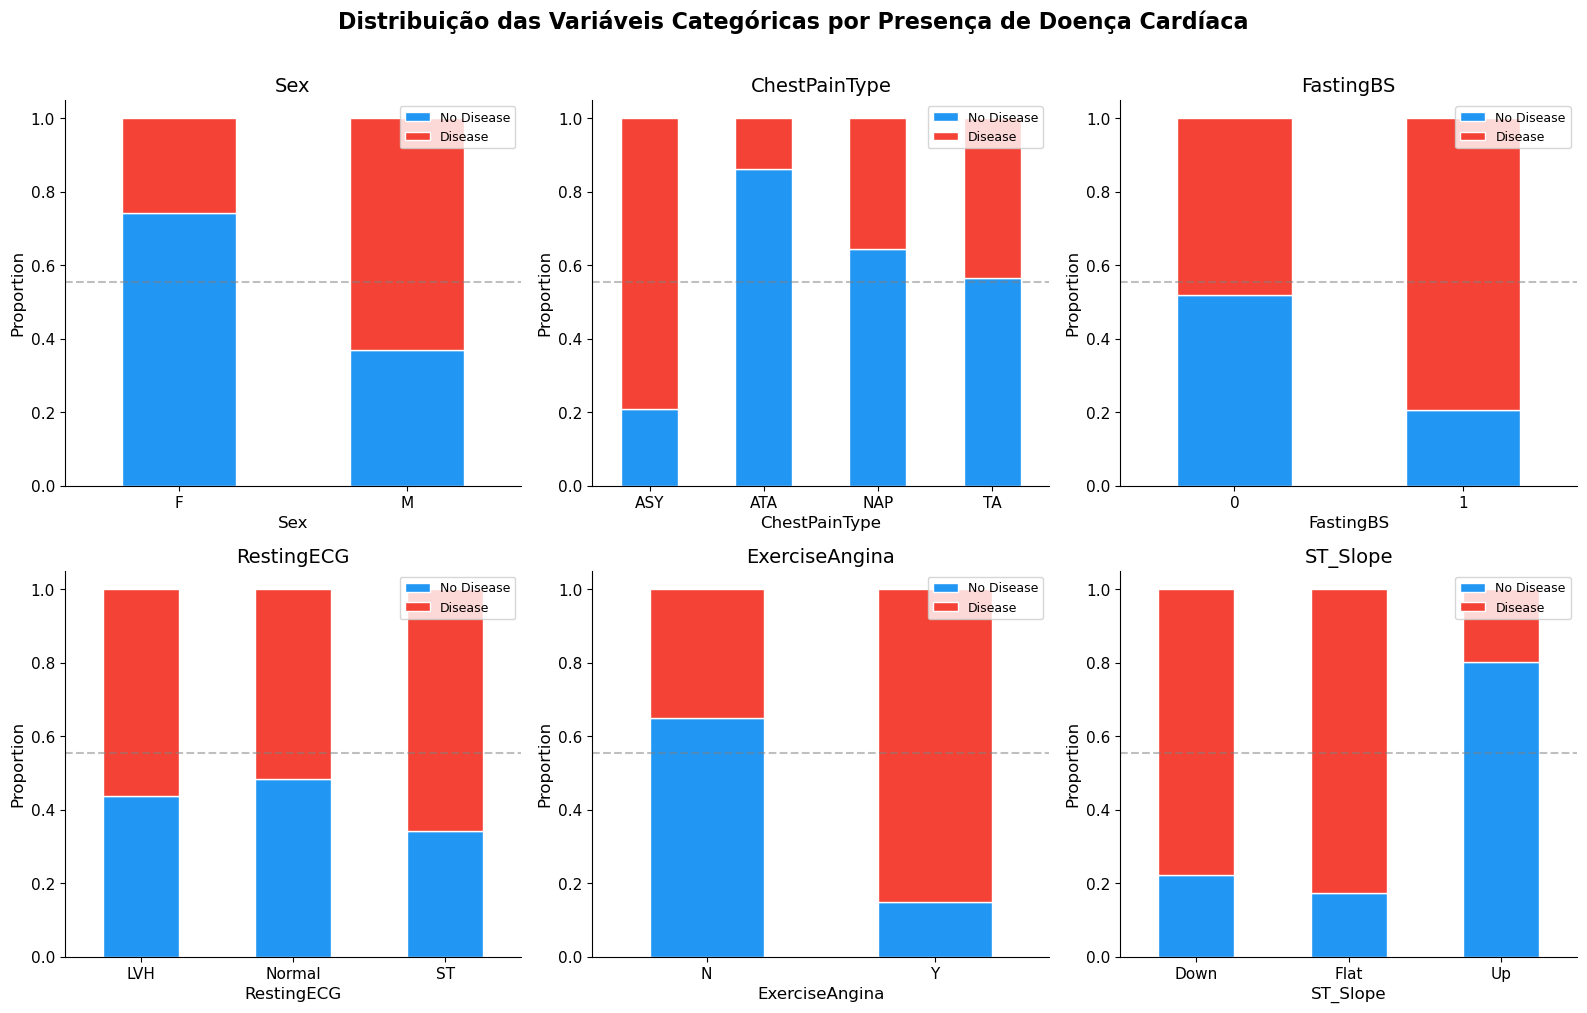

In [11]:
#Identificando as variáveis categóricas 
cat_cols = ["Sex", 'ChestPainType', 'FastingBS','RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.ravel(), cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS['no_disease'], COLORS['disease']], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['No Disease', 'Disease'], fontsize=9, loc='upper right')
    ax.axhline(df['HeartDisease'].mean(), color='gray', linestyle='--', alpha=0.5)

fig.suptitle("Distribuição das Variáveis Categóricas por Presença de Doença Cardíaca", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

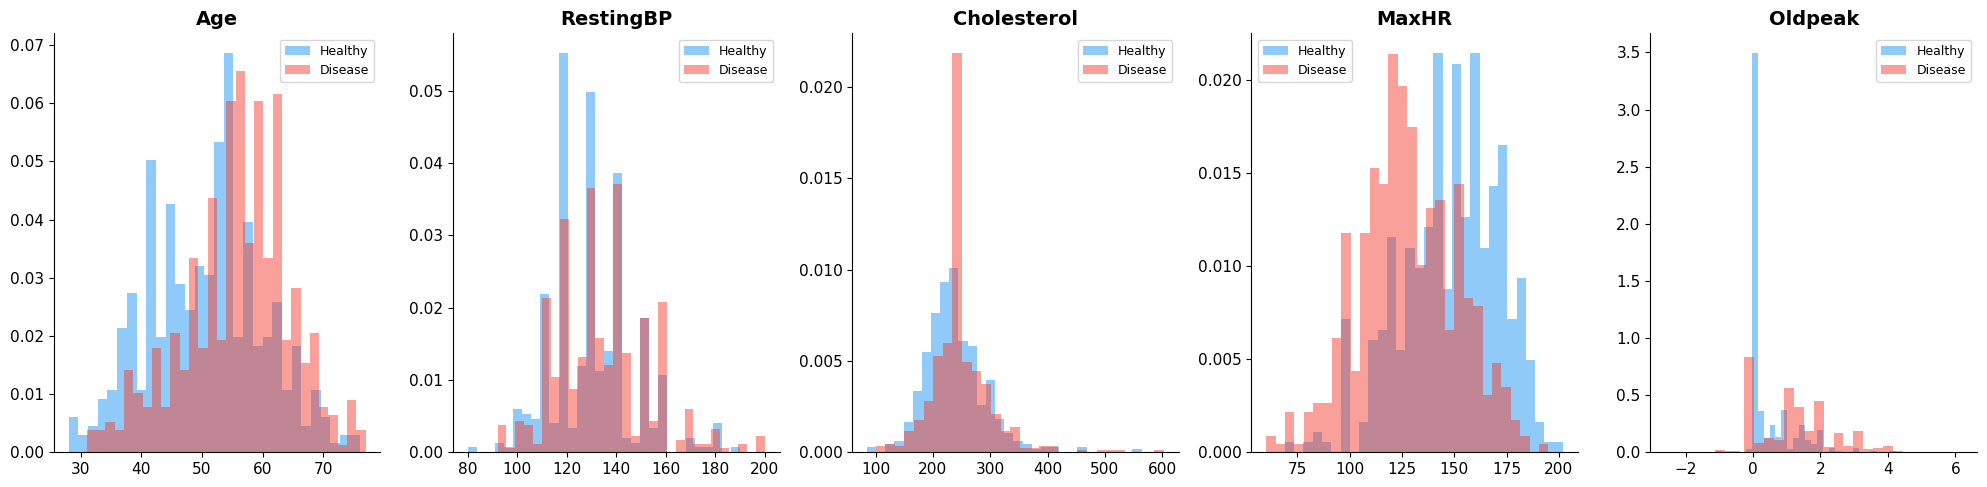

In [12]:
# Varíaveis númericas: Age, RestingBP, Cholesterol, MaxHR, Oldpeak
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    for label, color, name in [(0, COLORS['no_disease'], 'Healthy'), (1, COLORS['disease'], 'Disease')]:
        subset = df[df['HeartDisease'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

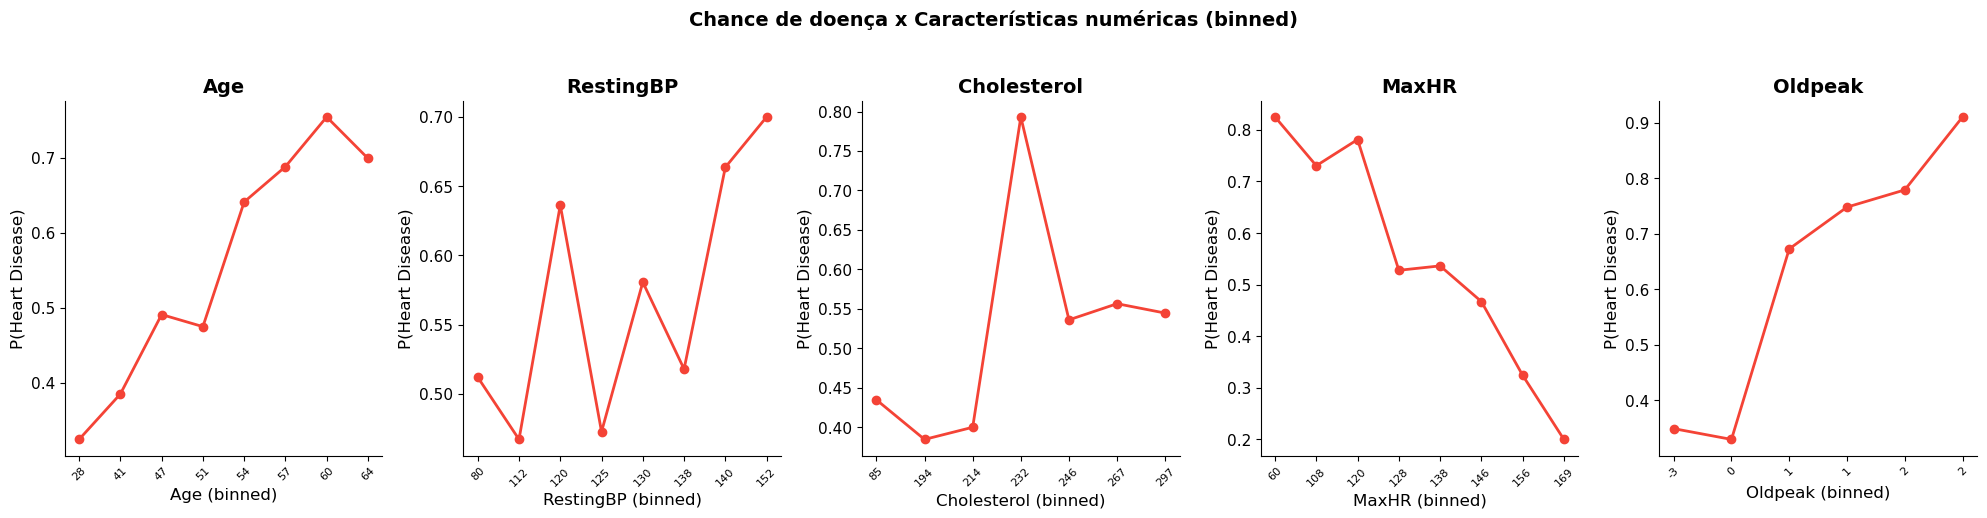

Age, MaxHR e RestingBP mostram relações mais lineares com a chance de doença — ótimos para LR.
Oldpeak tem uma relação não linear — pode precisar de transformação ou modelo mais flexível.
Cholasterol tem uma relação estranha, possivelmente devido aos zeros imputados — monitorar impacto no modelo.


In [13]:
# Verificação de linearidade: médias agrupadas (binned means) de características numéricas vs. taxa de doença
# Se a relação for aproximadamente monotônica, a Regressão Logística (LR) — com possíveis
#  transformações — funcionará bem.

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    # Criar bins usando qcut para garantir aproximadamente o mesmo número de amostras em cada bin
    bins = pd.qcut(df[col], q=8, duplicates='drop')
    grouped = df.groupby(bins, observed=True)['HeartDisease'].mean()
    
    ax.plot(range(len(grouped)), grouped.values, 'o-', color=COLORS['disease'], linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('P(Heart Disease)')
    ax.set_xlabel(f'{col} (binned)')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f'{x.left:.0f}' for x in grouped.index], rotation=45, fontsize=8)

fig.suptitle('Chance de doença x Características numéricas (binned)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Age, MaxHR e RestingBP mostram relações mais lineares com a chance de doença — ótimos para LR.')
print('Oldpeak tem uma relação não linear — pode precisar de transformação ou modelo mais flexível.')
print('Cholasterol tem uma relação estranha, possivelmente devido aos zeros imputados — monitorar impacto no modelo.')

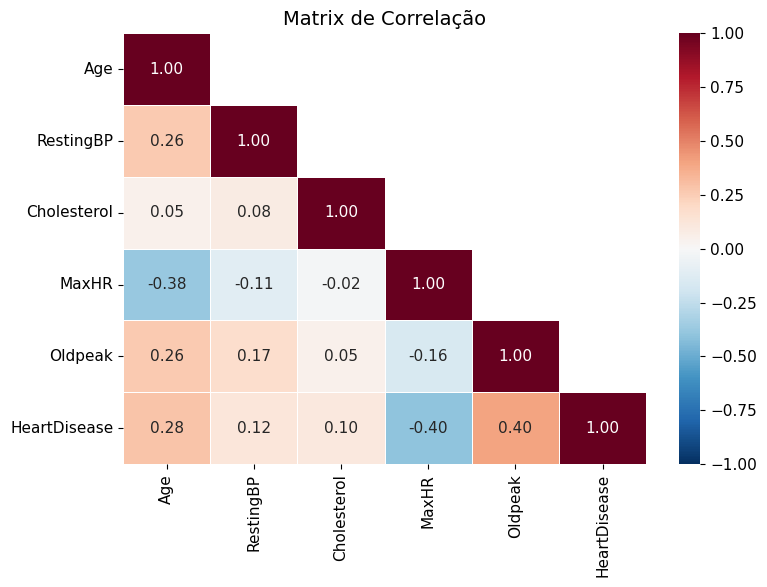

In [14]:
# Matrix de correlação entre as categórias númericas
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols + ['HeartDisease']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matrix de Correlação')
plt.tight_layout()
plt.show()

## 3.1. Conclusão da EAD
- Sex: M, tem maior predisposição de ter doenças cardíacas;
- ChestPainType: curiosamente os pacientes Assintomáticos são os que tem maior disposição em ter doenças cardíacas;
- FastingBS: 1, ou seja, glicemia em jejum maior que 120mg/dL;
- RestingECG: quem apresenta uma variação no ST, também aumenta o risco de doença cardíca;
- Exercise Angina: quando há esse fenômeno, também aumenta a chance de doença cardíaca;
- ST Slope: quando o ST apresenta uma modicação para cima aumenta o risco de doença cardíaca;
- Oldpeak (ST depression) e MaxHR são fortes indicadores númericos;
- Cholesterol: após termos imputados os 0 podemos ver que colesterol não é tão relevante para predissão (contudo é importante notar que imputamos dados para preencher os dados que estavam como 0)

# 4. Preprocessamento para o Modelos
Para utilizar algumas técnicas de Machine Learning precisamos de:
- Características numéricas escalonadas
- Características categóricas codificas 

In [15]:
# Para varíaveis numéricas vamos usar num_cols
#FastingBS já uma varíavel binária, então não precisa de transformação
var_bin = ['FastingBS']

#Varíaveis catergóricas
var_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']

#ST_Slope tem 3 categorias ordenadas: Up, Flat, Down
var_ordinal = ['ST_Slope']

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# stratify=y garante mesma proporção de doentes nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]} amostragem ({y_train.mean()*100:.1f}% doentes)")
print(f"Test:  {X_test.shape[0]} amostragem ({y_test.mean()*100:.1f}% doentes)")

Train: 734 amostragem (55.3% doentes)
Test:  184 amostragem (55.4% doentes)


In [16]:
#Contruindo a pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', var_bin),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), var_cat),
        ('ord', OrdinalEncoder(categories=[['Up', 'Flat', 'Down']]), var_ordinal)
    ],
    remainder='drop'
)

#Ajustando o dado e verificando a saída
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape after preprocessing: {X_train_processed.shape}")
print(f"Feature names after preprocessing:")
# Extraindo os nomes das features após o ColumnTransformer
num_names = num_cols
bin_names = var_bin
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(var_cat).tolist()
ord_names = var_ordinal
todas_as_features = num_names + bin_names + cat_names + ord_names
print(todas_as_features)


Shape after preprocessing: (734, 14)
Feature names after preprocessing:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope']


# 5. Baseline Logistic Regression

In [17]:
# Baseline: Logistic Regression sem regularização
lr_baseline = LogisticRegression(random_state=SEED, max_iter=1000)
lr_baseline.fit(X_train_processed, y_train)

y_pred = lr_baseline.predict(X_test_processed)
y_prob = lr_baseline.predict_proba(X_test_processed)[:, 1]

print('======= Baseline Logistic Regression =======')
print(f"\n{classification_report(y_test, y_pred, target_names=['Healthy', 'Disease'])}")
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')
print(f'Average Precision: {average_precision_score(y_test, y_prob):.3f}')
print(f'Brier Score: {brier_score_loss(y_test, y_prob):.3f}')

======= Baseline Logistic Regression =======

              precision    recall  f1-score   support

     Healthy       0.88      0.82      0.85        82
     Disease       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.907
Average Precision: 0.900
Brier Score: 0.111


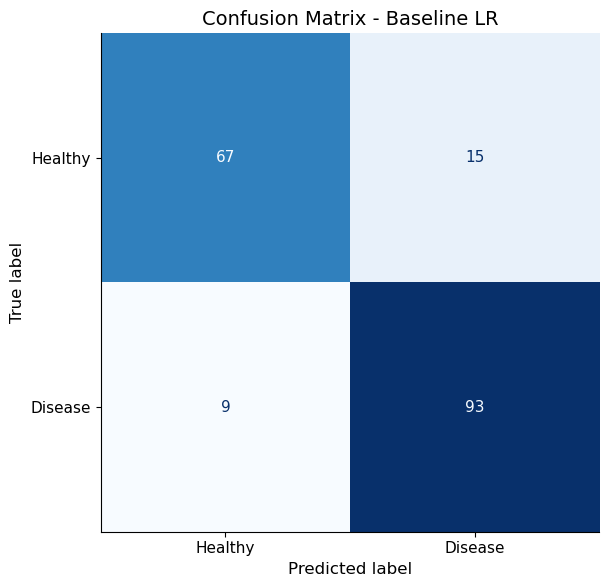

In [18]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Healthy', 'Disease'],
    cmap='Blues', ax=ax, colorbar=False
)

ax.set_title('Confusion Matrix - Baseline LR')
plt.tight_layout()
plt.show()

# 6. Interpretando esses Dados

In [19]:
# Extraindo e plotando coeficientes
coef_df = pd.DataFrame({
    'Feature': todas_as_features, 
    'Coefficient': lr_baseline.coef_[0],
    'Odds_Ratio': np.exp(lr_baseline.coef_[0])
}).sort_values('Coefficient')

print('Intercept:', f'{lr_baseline.intercept_[0]:.4f}')
print(f'\nCoefficients and Odds Ratios:')
print(coef_df.to_string(index=False, float_format='{:.3f}'.format))

Intercept: -1.5337

Coefficients and Odds Ratios:
          Feature  Coefficient  Odds_Ratio
ChestPainType_ATA       -1.607       0.201
ChestPainType_NAP       -1.460       0.232
 ChestPainType_TA       -1.080       0.340
            MaxHR       -0.357       0.700
RestingECG_Normal       -0.155       0.856
    RestingECG_ST       -0.129       0.879
        RestingBP        0.003       1.003
              Age        0.042       1.043
      Cholesterol        0.135       1.145
          Oldpeak        0.188       1.207
 ExerciseAngina_Y        0.955       2.600
        FastingBS        1.094       2.985
            Sex_M        1.213       3.362
         ST_Slope        1.754       5.779


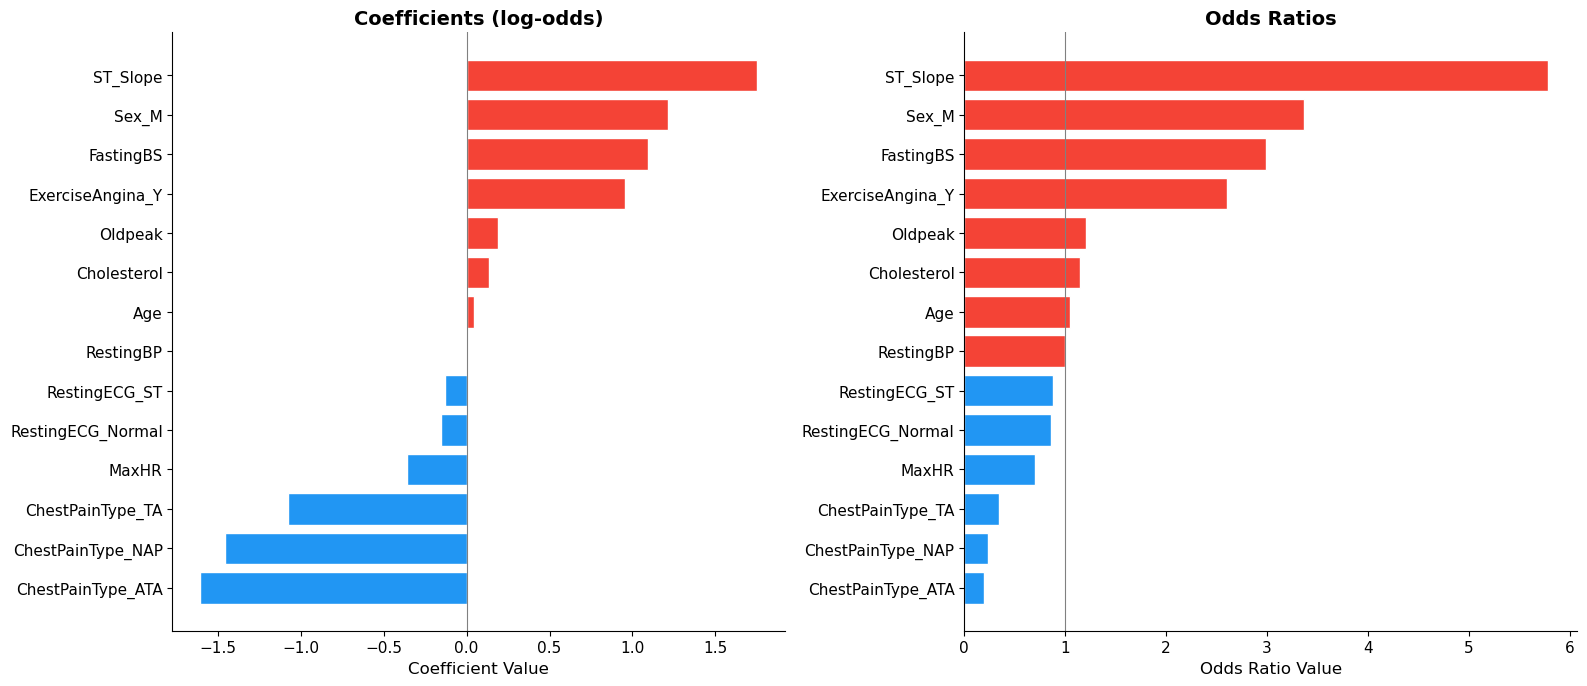

In [20]:
# Plotando os coeficientes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# COeficientes
colors = [COLORS['disease'] if c > 0 else COLORS['no_disease'] for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Coefficients (log-odds)', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Odds Ratios
or_sorted = coef_df.sort_values('Odds_Ratio')
colors_or =[COLORS['disease'] if c > 1 else COLORS['no_disease'] for c in or_sorted['Odds_Ratio']]
axes[1].barh(or_sorted['Feature'], or_sorted['Odds_Ratio'], color=colors_or, edgecolor='white')
axes[1].axvline(1, color='gray', linewidth=0.8)
axes[1].set_title('Odds Ratios', fontweight='bold')
axes[1].set_xlabel('Odds Ratio Value')

plt.tight_layout()
plt.show()

In [21]:
# Intrerpretação dos coeficientes
print('========= Interpretação dos Coeficientes =========')
print()

top_risk = coef_df.nlargest(5, 'Coefficient')
top_protective = coef_df.nsmallest(5, 'Coefficient')

print('Top 5 maiores fatores de risco')
for _, row in top_risk.iterrows():
    direction = 'increases' if row['Odds_Ratio'] > 1 else 'decreases'
    factor = row['Odds_Ratio'] if row['Odds_Ratio'] > 1 else 1/row['Odds_Ratio']   
    print(f"  - {row['Feature']:30s}: OR={row['Odds_Ratio']:.3f}" f"→ {direction} odds by {(factor-1)*100:.0f}%")

print(f'\nTOP 5 PROTECTIVE FACTORS (decrease disease probability):')
for _, row in top_protective.iterrows():
    direction = 'increases' if row['Odds_Ratio'] > 1 else 'decreases'
    factor = row['Odds_Ratio'] if row['Odds_Ratio'] > 1 else 1/row['Odds_Ratio']
    print(f"  {row['Feature']:30s} OR={row['Odds_Ratio']:.2f}  "
          f"→ {direction} odds by {(factor-1)*100:.0f}%")

========= Interpretação dos Coeficientes =========

Top 5 maiores fatores de risco
  - ST_Slope                      : OR=5.779→ increases odds by 478%
  - Sex_M                         : OR=3.362→ increases odds by 236%
  - FastingBS                     : OR=2.985→ increases odds by 199%
  - ExerciseAngina_Y              : OR=2.600→ increases odds by 160%
  - Oldpeak                       : OR=1.207→ increases odds by 21%

TOP 5 PROTECTIVE FACTORS (decrease disease probability):
  ChestPainType_ATA              OR=0.20  → decreases odds by 399%
  ChestPainType_NAP              OR=0.23  → decreases odds by 331%
  ChestPainType_TA               OR=0.34  → decreases odds by 194%
  MaxHR                          OR=0.70  → decreases odds by 43%
  RestingECG_Normal              OR=0.86  → decreases odds by 17%


In [22]:
# Comparando os tipos de regularizção com CV
resultados = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

configs = [
    ('L2 (Ridge)', 'l2', 'lbfgs'),
    ('L1 (Lasso)', 'l1', 'liblinear'),
    ("ElasticNet", 'elasticnet', 'saga'),
    ('No regularization', None, 'lbfgs'),
]

for name, penalty, solver in configs:
    kwargs = {'penalty': penalty, 'solver': solver, 'random_state': SEED, 'max_iter': 5000}
    if penalty == 'elasticnet':
        kwargs['l1_ratio'] = 0.5  # Equal mix of L1 and L2

    model = LogisticRegression(**kwargs)
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc')
    resultados.append({
        'Penalty': name,
        'Mean AUC': scores.mean(),
        'Std AUC': scores.std()
    })

reg_df = pd.DataFrame(resultados)
print(reg_df.to_string(index=False, float_format='{:.3f}'.format))

          Penalty  Mean AUC  Std AUC
       L2 (Ridge)     0.915    0.036
       L1 (Lasso)     0.915    0.036
       ElasticNet     0.916    0.035
No regularization     0.914    0.037


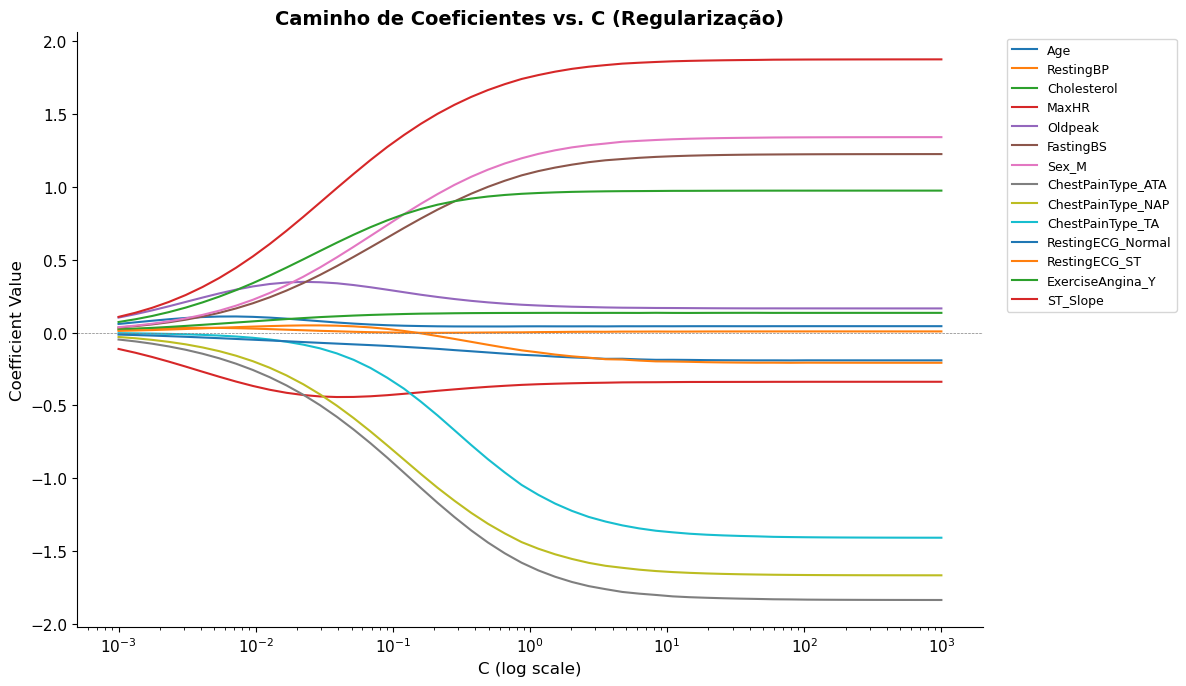

Left side (small C): strong regularization, all coefficients squeezed toward zero.
Right side (large C): weak regularization, coefficients reach their unrestricted values.
The stable features on the right are the ones the model is most confident about.


In [ ]:
# Caminho de regularização - Como os coeficientes mudam com diferentes valores de C (força da regularização)

c_values = np.logspace(-3, 3, 50)
coef_paths = {feat: [] for feat in todas_as_features}

for c in c_values:
    model = LogisticRegression(C=c, penalty="l2", random_state=SEED, max_iter=5000)
    model.fit(X_train_processed, y_train)
    for i, feat in enumerate(todas_as_features):
        coef_paths[feat].append(model.coef_[0][i])

fig, ax = plt.subplots(figsize=(12,7))
for feat in todas_as_features:
    ax.plot(c_values, coef_paths[feat], linewidth=1.5, label=feat)

ax.set_xscale('log')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Caminho de Coeficientes vs. C (Regularização)', fontweight='bold')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Coefficient Value')
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print('Lado esquerdo ($C$ pequeno): regularização forte, todos os coeficientes são pressionados em direção a zero.')
print('Lado direito ($C$ grande): regularização fraca, os coeficientes atingem seus valores irrestritos.')
print('As características (features) estáveis à direita são aquelas sobre as quais o modelo tem mais confiança.')

In [24]:
# L1 seleção - qual variável é mantida quando for aplicada a regularização L1?
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=SEED, max_iter=5000)
lr_l1.fit(X_train_processed, y_train)

l1_coefs = pd.DataFrame({
    'Feature': todas_as_features,
    'Coefficient': lr_l1.coef_[0],
    'Kept': lr_l1.coef_[0] != 0
})

print(f'L1 with C=0.5 keeps {l1_coefs['Kept'].sum()} / {len(l1_coefs)} features:')
kept = l1_coefs[l1_coefs['Kept']].sort_values('Coefficient', key=abs, ascending=False)
print(kept[['Feature', 'Coefficient']].to_string(index=False, float_format='{:.3f}'.format))

dropped = l1_coefs[~l1_coefs['Kept']]['Feature'].tolist()
if dropped:
    print(f'\nVaríaveis descartadas: {", ".join(dropped)}')

L1 with C=0.5 keeps 12 / 14 features:
          Feature  Coefficient
         ST_Slope        1.698
ChestPainType_ATA       -1.609
ChestPainType_NAP       -1.420
            Sex_M        0.997
        FastingBS        0.981
 ChestPainType_TA       -0.909
 ExerciseAngina_Y        0.885
            MaxHR       -0.349
          Oldpeak        0.184
      Cholesterol        0.104
RestingECG_Normal       -0.082
              Age        0.028

Dropped features (set to zero): RestingBP, RestingECG_ST


Best C: 0.6158


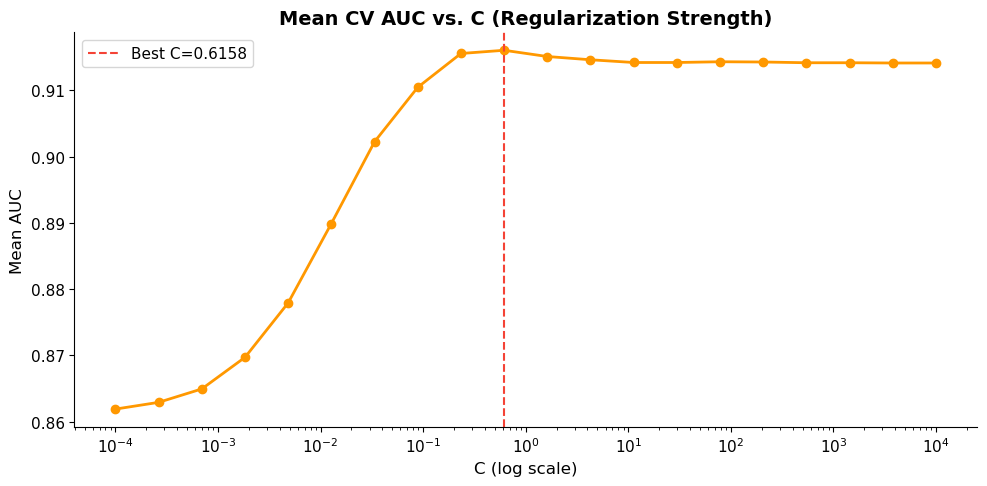

======= Logistic Regression with CV-selected C =======

              precision    recall  f1-score   support

     Healthy       0.88      0.82      0.85        82
     Disease       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.908


In [25]:
# Achando um bom valor de C para L1 usando LogisticRegressionCV
lr_cv = LogisticRegressionCV(
    Cs=20, 
    cv= StratifiedKFold(5, shuffle=True, random_state=SEED),  
    scoring='roc_auc',
    penalty='l2',
    random_state=SEED, 
    max_iter=5000,
    n_jobs=-1
)
lr_cv.fit(X_train_processed, y_train)

print(f'Best C: {lr_cv.C_[0]:.4f}')

#Plot AUC vs C

mean_scores = lr_cv.scores_[1].mean(axis=0)
cs= lr_cv.Cs_

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cs, mean_scores, 'o-', color=COLORS['accent'], linewidth=2)
ax.axvline(lr_cv.C_[0], color=COLORS['disease'], linestyle='--', label=f'Best C={lr_cv.C_[0]:.4f}')
ax.set_xscale('log')
ax.set_title('Mean CV AUC vs. C (Regularization Strength)', fontweight='bold')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Mean AUC')
ax.legend()
plt.tight_layout()
plt.show()

#Evaluate on test set
y_pred_cv = lr_cv.predict(X_test_processed)
y_prob_cv = lr_cv.predict_proba(X_test_processed)[:, 1]

print('======= Logistic Regression with CV-selected C =======')
print(f"\n{classification_report(y_test, y_pred_cv, target_names=['Healthy', 'Disease'])}")
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_cv):.3f}')

# 7. Calibrando o Modelo

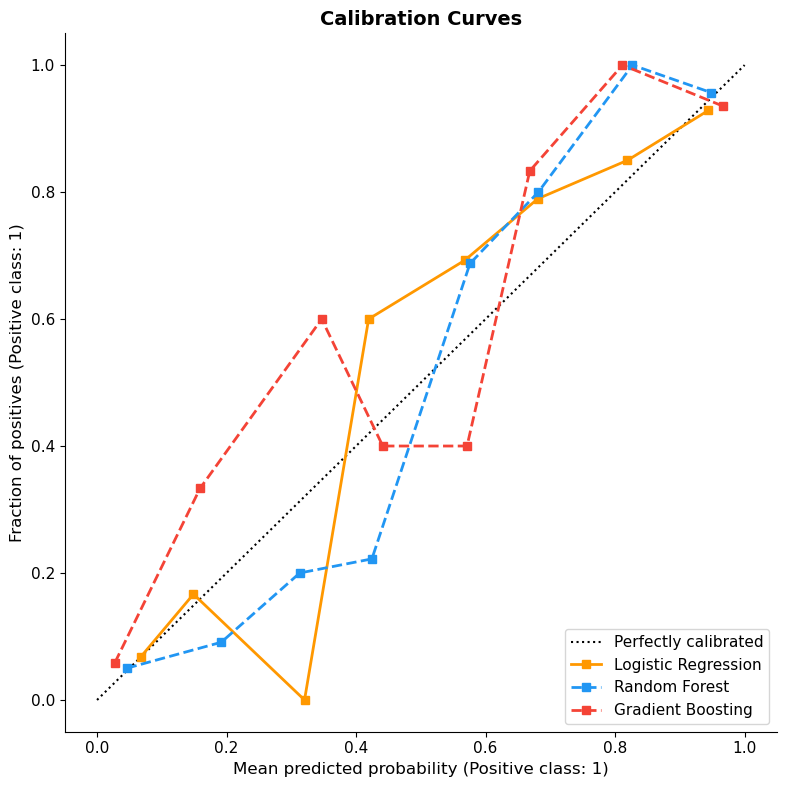

Brier Scores (lower = better calibration):
  Logistic Regression: 0.1111
  Random Forest:       0.0954
  Gradient Boosting:   0.0848

Closer to the diagonal = better calibrated. LR is typically the most calibrated.


In [26]:
# Train tree-based models for comparison
rf= RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

gb = GradientBoostingClassifier(n_estimators=200, random_state=SEED)
gb.fit(X_train_processed, y_train)
y_prob_gb = gb.predict_proba(X_test_processed)[:, 1]

#Plotando a calibração 
fig, ax = plt.subplots(figsize=(8,8))

CalibrationDisplay.from_predictions(
    y_test, y_prob_cv, n_bins=8, name='Logistic Regression', ax=ax, color=COLORS['accent'], linewidth=2
)
CalibrationDisplay.from_predictions(
    y_test, y_prob_rf, n_bins=8, name='Random Forest', ax=ax, color=COLORS['no_disease'], linewidth=2, linestyle='--'
)
CalibrationDisplay.from_predictions(
    y_test, y_prob_gb, n_bins=8, name='Gradient Boosting', ax=ax, color=COLORS['disease'], linewidth=2, linestyle='--'
)

ax.set_title('Calibration Curves', fontweight='bold')
plt.tight_layout()
plt.show()

print('Brier Scores (lower = better calibration):')
print(f'  Logistic Regression: {brier_score_loss(y_test, y_prob_cv):.4f}')
print(f'  Random Forest:       {brier_score_loss(y_test, y_prob_rf):.4f}')
print(f'  Gradient Boosting:   {brier_score_loss(y_test, y_prob_gb):.4f}')
print('\nCloser to the diagonal = better calibrated. LR is typically the most calibrated.')

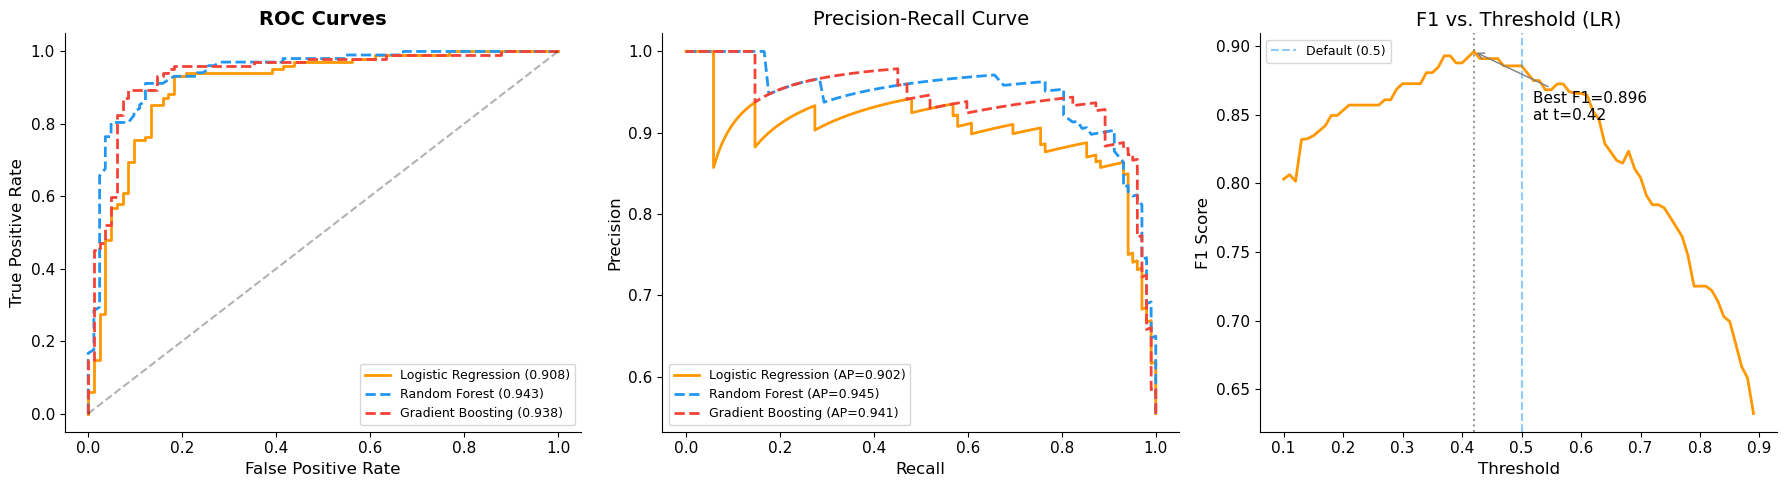

In [27]:
#Calibrando a seleção e ROC/PR Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve comparison
for y_p, name, color, ls in [(y_prob_cv, 'Logistic Regression', COLORS['accent'], '-'),
                            (y_prob_rf, 'Random Forest', COLORS['no_disease'], '--'),
                            (y_prob_gb, 'Gradient Boosting', COLORS['disease'], '--')]:
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc = roc_auc_score(y_test, y_p)
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})", color=color, linewidth=2, linestyle=ls)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Precision-Recall curve comparison 
for y_p, name, color, ls in [(y_prob_cv, 'Logistic Regression', COLORS['accent'], '-'),
                            (y_prob_rf, 'Random Forest', COLORS['no_disease'], '--'),
                            (y_prob_gb, 'Gradient Boosting', COLORS['disease'], '--')]:
    precision, recall, _ = precision_recall_curve(y_test, y_p)
    ap = average_precision_score(y_test, y_p)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2, linestyle=ls)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

#Threshold selection for LR
thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_test, (y_prob_cv >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
axes[2].plot(thresholds, f1s, color=COLORS['accent'], linewidth=2)
axes[2].axvline(best_t, color='gray', linestyle=':', alpha=0.8)
axes[2].axvline(0.5, color=COLORS['no_disease'], linestyle='--', alpha=0.5, label='Default (0.5)')
axes[2].annotate(f'Best F1={max(f1s):.3f}\nat t={best_t:.2f}',
                xy=(best_t, max(f1s)), xytext=(best_t + 0.1, max(f1s) - 0.05),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)
axes[2].set_title('F1 vs. Threshold (LR)')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# 8. Comparação Final 

In [29]:
# Comparação final dos modelos
models_compare = {
    'Logistic Regression': y_prob_cv, 
    'Random Forest': y_prob_rf,
    'Gradient Boosting': y_prob_gb
}
comparison = []

for name, y_p in models_compare.items():
    y_pred_comp = (y_p >= 0.5).astype(int)
    comparison.append({
        'Model': name,
        'Accuracy': (y_pred_comp == y_test).mean(),
        'F1': f1_score(y_test, y_pred_comp),
        'ROC-AUC': roc_auc_score(y_test, y_p),
        'PR-AUC': average_precision_score(y_test, y_p),
        'Brier': brier_score_loss(y_test, y_p),
    })
comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False, float_format='%.4f'))
print('\nA Regressão Logística é competitiva com modelos baseados em árvores neste conjunto de dados.')
print('E ela te entrega coeficientes interpretáveis e probabilidades calibradas "de brinde" (sem custo adicional.')

              Model  Accuracy     F1  ROC-AUC  PR-AUC  Brier
Logistic Regression    0.8696 0.8857   0.9079  0.9016 0.1111
      Random Forest    0.8913 0.9029   0.9426  0.9450 0.0954
  Gradient Boosting    0.8913 0.9010   0.9376  0.9414 0.0848

A Regressão Logística é competitiva com modelos baseados em árvores neste conjunto de dados.
E ela te entrega coeficientes interpretáveis e probabilidades calibradas "de brinde" (sem custo adicional.


# 9. Conclusão final 
O projeto nasceu de uma constatação epidemiológica grave — doenças cardíacas isquêmicas são a principal causa de morte no mundo, responsáveis por cerca de 9,1 milhões de óbitos em 2021, segundo dados da OMS. Diante disso, o objetivo central não foi apenas "construir um modelo de ML", mas responder a uma pergunta com implicações clínicas reais: *é possível, a partir de variáveis clínicas acessíveis, identificar com confiança pacientes em risco de doença cardíaca?*. Ao dividir o notebook em duas parte, uma que contempla até a EDA e outra o preprocessamento para o ML, poderemos ver que o que foi aprendido em cada uma delas é:  

## Parte 1 — Entendimento e Exploração dos Dados
 
- Dataset com **918 observações** e **11 variáveis clínicas**, combinado de 5 bases independentes (Cleveland, Hungria, Suíça, Long Beach e Statlog)
- **172 registros (~19%)** apresentavam colesterol = 0 — valor clinicamente impossível, tratado como dado ausente
- Colesterol imputado com **mediana segmentada por grupo** (`HeartDisease = 0` e `HeartDisease = 1`), preservando as diferenças de distribuição entre os grupos
- Nenhum outro valor nulo ou duplicata encontrado
**Principais achados da EDA:**
 
- `ST_Slope` — maior poder discriminativo entre doentes e saudáveis; comportamento do segmento ST no esforço é marcador clínico consagrado de isquemia
- `ExerciseAngina` e `Oldpeak` — distribuições claramente distintas entre os grupos
- `ChestPainType ASY` (assintomático) — aparece de forma desproporcional em pacientes doentes: ausência de dor clássica não significa ausência de risco
- `MaxHR` — correlação **negativa** com doença: quanto menor a frequência cardíaca máxima, maior o risco
- `Oldpeak` apresenta relação **não linear** com o desfecho, sugerindo vantagem para modelos mais flexíveis
---
 
## Parte 2 — Pré-processamento e Modelagem
 
- Divisão treino/teste **80/20 estratificada**, mantendo a proporção de doentes em ambos os conjuntos
- Pipeline construído com `ColumnTransformer` + `sklearn.Pipeline`, garantindo que as transformações do treino sejam reproduzidas automaticamente na inferência
**Encoding por tipo de variável:**
 
- `StandardScaler` → variáveis numéricas contínuas (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`)
- `passthrough` → variável binária (`FastingBS`), já em formato adequado
- `OneHotEncoder` → variáveis categóricas nominais (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`)
- `OrdinalEncoder` com ordem `[Up → Flat → Down]` → `ST_Slope`, pois existe uma progressão clínica real entre os valores
**Modelos treinados e comparação final:**
 
| Modelo | Accuracy | F1 | ROC-AUC | PR-AUC | Brier |
|---|---|---|---|---|---|
| Logistic Regression | 0.8696 | 0.8857 | 0.9079 | 0.9016 | 0.1111 |
| Random Forest | 0.8913 | 0.9029 | 0.9426 | 0.9450 | 0.0954 |
| Gradient Boosting | 0.8913 | 0.9010 | 0.9376 | 0.9414 | 0.0848 |
 
- **Random Forest** selecionado como modelo final pelo maior **Recall (~94%)** e **ROC-AUC (~94%)** — em contexto clínico, minimizar falsos negativos (doença não detectada) é a prioridade
- As variáveis de maior peso em ambos os modelos foram `ST_Slope`, `ExerciseAngina`, `Oldpeak` e `ChestPainType` — todas relacionadas à resposta cardiovascular ao esforço físico

## Adendos

Ao final do notebook, não temos apenas um modelo treinado — temos um **pipeline reproduzível**, com decisões documentadas e clinicamente justificadas em cada etapa. A combinação de boas práticas de engenharia de ML (Pipeline + ColumnTransformer + validação cruzada estratificada) com raciocínio clínico aplicado (Recall como métrica principal, encoding sensível ao domínio, imputação segmentada) representa o caminho correto para projetos de ML em saúde.

### O que fazer a partir daqui 
O objetivo declarado do projeto é transformar esse pipeline em uma ferramenta de apoio à decisão clínica — um dashboard interativo onde médicos possam inserir os dados de um paciente e receber, em tempo real, a probabilidade de risco cardíaco. Existem diferentes abordagens para isso:

### Opção A — Dashboard Web Interativo com Streamlit (recomendado para início)
 
**Streamlit** é um framework Python que permite transformar um script de ML em uma aplicação web funcional com poucas linhas de código. Para o contexto do projeto, essa é a opção de menor atrito para chegar a uma versão funcional rapidamente.
 
**Como funcionaria:**
 
1. O modelo treinado (Pipeline completo) é serializado com `joblib` — um único arquivo `.pkl` que contém o pré-processador e o Random Forest juntos.
2. A aplicação Streamlit carrega esse arquivo e apresenta um formulário com os 11 campos clínicos.
3. O médico preenche os dados do paciente, clica em "Calcular Risco" e recebe:
   - A **probabilidade numérica** (ex: 73%)
   - O **rótulo de risco** (Baixo / Médio / Alto) com as faixas conservadoras já definidas (<30%, 30–60%, >60%)
   - Um **gráfico de contribuição de variáveis** (SHAP values) explicando *por que* o modelo chegou àquela conclusão

### Opção B — Dashboard Power BI com integração Python
 
Como o projeto já possui um dashboard Power BI em construção, uma alternativa é estender esse ambiente com predições em tempo real. O Power BI permite executar scripts Python dentro do próprio relatório, o que possibilita carregar o modelo serializado e computar predições sobre novos dados inseridos via parâmetros de filtro.
 
**Como funcionaria:**
 
1. O usuário cria um "paciente virtual" ajustando slicers e parâmetros no Power BI.
2. Um script Python embutido no visual carrega o Pipeline treinado e computa a probabilidade para aquele conjunto de parâmetros.
3. O resultado é exibido em um visual customizado com indicadores de risco.